# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica y se aplica a dos diferentes datasets.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Manejo de rutas
import os
# Cálculo numérico
import numpy as np

# Manejo de datos (nuevo)
import pandas as pd

# Gráficos
from matplotlib import pyplot

# Optimización
from scipy import optimize

%matplotlib inline

In [9]:
import pandas as pd

path = '/content/drive/MyDrive/colab/Practicas/01/diabetes_012_health_indicators_BRFSS2015.csv'

df = pd.read_csv(path)

print(df.head())

   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

In [10]:
# Convertir a binario: 0 = no diabetes, 1 = diabetes (1 o 2)
df['Diabetes_binary'] = df['Diabetes_012'].apply(lambda x: 1 if x > 0 else 0)

# Seleccionar variables
X = df[['BMI', 'Age']].values
y = df['Diabetes_binary'].values

print(X[:5])
print(y[:5])

[[40.  9.]
 [25.  7.]
 [28.  9.]
 [27. 11.]
 [24. 11.]]
[0 0 0 0 0]


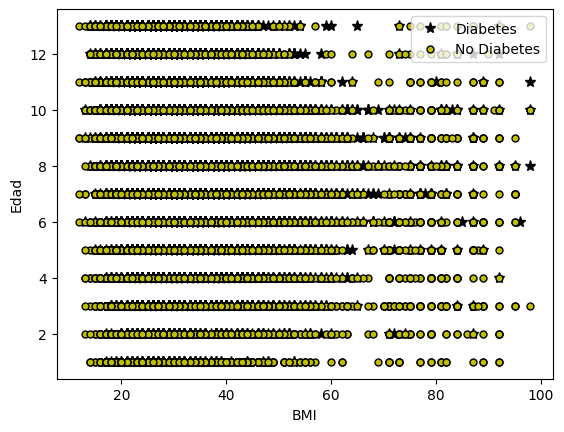

In [11]:
def plotData(X, y):
    fig = pyplot.figure()

    pos = y == 1
    neg = y == 0

    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=8)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=5)

# Graficar
plotData(X, y)
pyplot.xlabel('BMI')
pyplot.ylabel('Edad')
pyplot.legend(['Diabetes', 'No Diabetes'])

In [12]:
def sigmoid(z):
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

# Prueba
z = [-10, 0, 10]
print(sigmoid(z))

[4.53978687e-05 5.00000000e-01 9.99954602e-01]


In [13]:
m, n = X.shape

# Agregar columna de unos
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [14]:
def calcularCosto(theta, X, y):
    m = y.size

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [15]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))

        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

Theta: [-0.00453325 -0.04897729 -0.01411962]


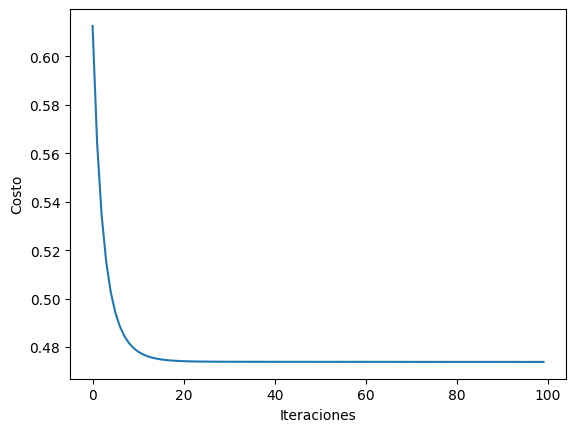

In [16]:
alpha = 0.001
num_iters = 100

theta = np.zeros(n + 1)

theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Gráfica del costo
pyplot.plot(np.arange(len(J_history)), J_history)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo')

print("Theta:", theta)

In [17]:
def costFunction(theta, X, y):
    m = y.size

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    grad = (1 / m) * (h - y).dot(X)

    return J, grad

In [18]:
initial_theta = np.zeros(n + 1)

options = {'maxiter': 400}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

theta = res.x

print("Costo final:", res.fun)
print("Theta optimizado:", theta)

/tmp/ipykernel_613/4045575052.py:5: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


Costo final: 0.39077250676561054
Theta optimizado: [-6.38114875  0.0931893   0.22624971]


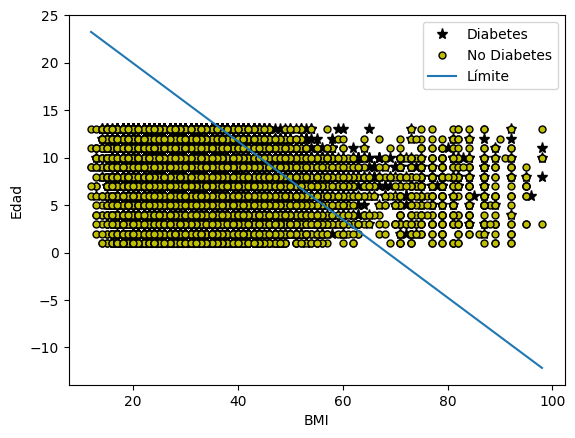

In [19]:
def plotDecisionBoundary(theta, X, y):

    plotData(X[:, 1:3], y)

    plot_x = np.array([np.min(X[:, 1]), np.max(X[:, 1])])

    plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

    pyplot.plot(plot_x, plot_y)

    pyplot.xlabel('BMI')
    pyplot.ylabel('Edad')
    pyplot.legend(['Diabetes', 'No Diabetes', 'Límite'])

plotDecisionBoundary(theta, X, y)

In [20]:
def predict(theta, X):
    return np.round(sigmoid(X.dot(theta.T)))

In [21]:
# Ejemplo de predicción (BMI=30, Edad=50)
prob = sigmoid(np.dot([1, 30, 50], theta))
print("Probabilidad de diabetes:", prob)

# Precisión
p = predict(theta, X)
print('Precisión del modelo: {:.2f}%'.format(np.mean(p == y) * 100))

Probabilidad de diabetes: 0.9995594368058783
Precisión del modelo: 84.09%


In [22]:
# Varias personas
personas = np.array([
    [1, 30, 50],  # alto riesgo
    [1, 22, 25],  # bajo riesgo
    [1, 35, 60],  # muy alto
    [1, 28, 40]   # medio
])

# Probabilidades
probs = sigmoid(personas.dot(theta))

# Predicciones
preds = np.round(probs)

print("Probabilidades:", probs)
print("Predicciones:", preds)

Probabilidades: [0.99955944 0.7900553  0.99997121 0.99492399]
Predicciones: [1. 1. 1. 1.]
